0      ADBL
1       API
2      HATH
3    HATHPO
4      AKPL
Name: Symbol, dtype: str

===== Processing ADBL =====
   Close  Decayed_Sentiment
0  255.0                0.0
1  138.0                0.0
2  125.0                0.0
3  122.0                0.0
4  118.0                0.0


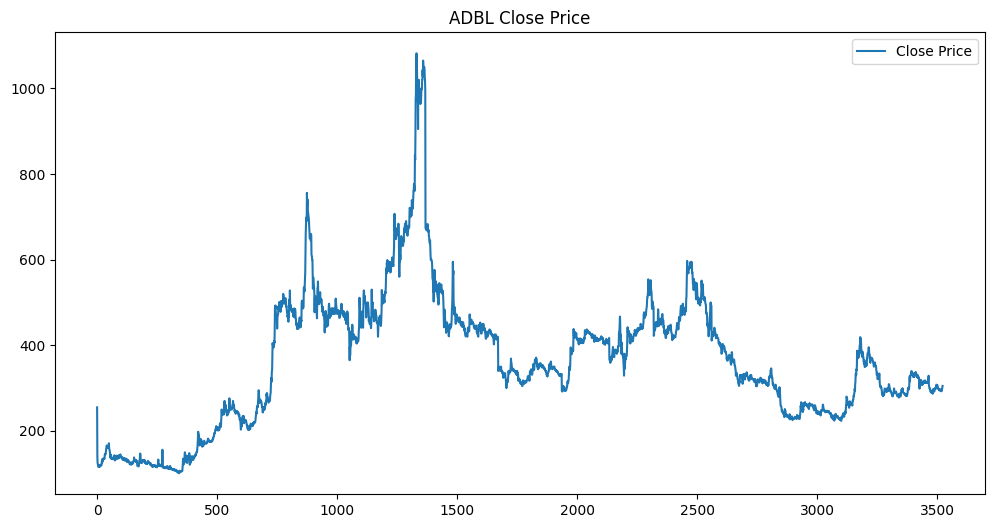

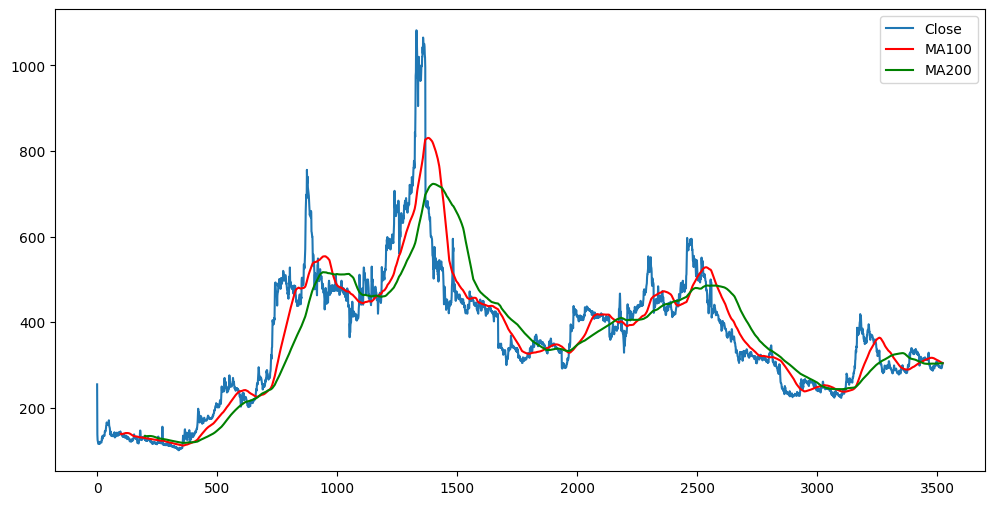

x_train shape: (2366, 100, 2)


/mnt/d/spa/python/venv/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 22s 168ms/step - loss: 0.0233 - val_loss: 9.6572e-04
Epoch 2/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 9s 151ms/step - loss: 0.0067 - val_loss: 0.0033
Epoch 3/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 8s 142ms/step - loss: 0.0057 - val_loss: 0.0054
Epoch 4/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 12s 194ms/step - loss: 0.0056 - val_loss: 0.0012
Epoch 5/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 9s 144ms/step - loss: 0.0043 - val_loss: 0.0018
Epoch 6/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 9s 144ms/step - loss: 0.0043 - val_loss: 0.0021
Epoch 7/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 9s 143ms/step - loss: 0.0044 - val_loss: 0.0017
Epoch 8/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 10s 172ms/step - loss: 0.0040 - val_loss: 8.5148e-04
Epoch 9/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 13s 217ms/step - loss: 0.0042 - val_loss: 5.8132e-04
Epoch 10/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 8s 141ms/step - loss: 0.0042 - val_loss: 9.6286e-04
Epoch 11/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 8s 136ms/step - loss: 0.0036 - val_loss: 5.7893e-04
Epoch 12/50
60/60 ━━━━━━━━━━

Model saved → ../DATA-HTML-STOCK/Models/ADBL_lstm.h5
x_test shape: (1057, 100, 2)
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 65ms/step

===== Metrics for ADBL =====
MSE  : 737.5476
RMSE : 27.1578
MAE  : 23.2826
R²   : 0.8818
MAPE : 8.0918%
Accuracy (100 - MAPE): 91.9082%


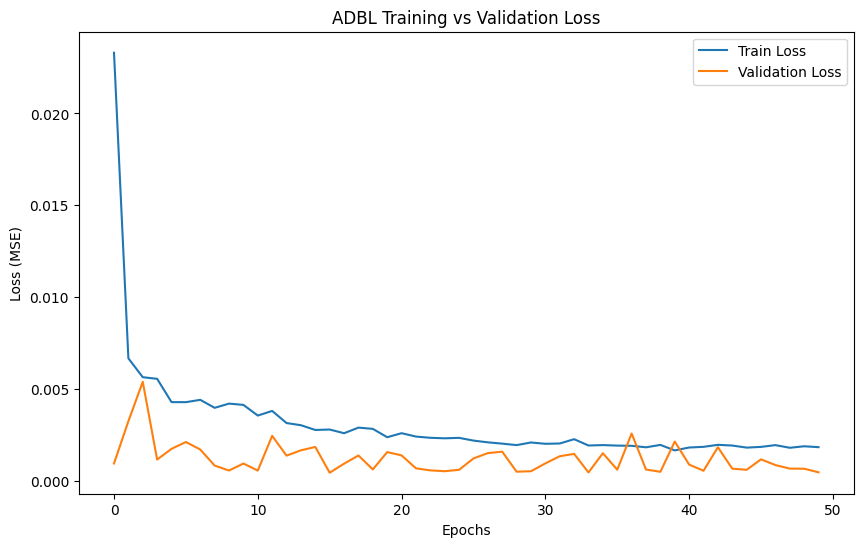

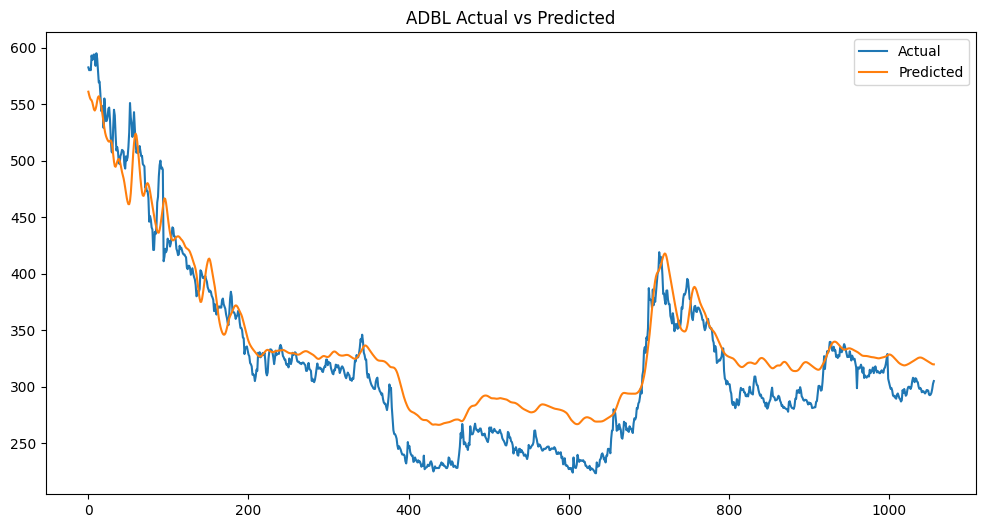

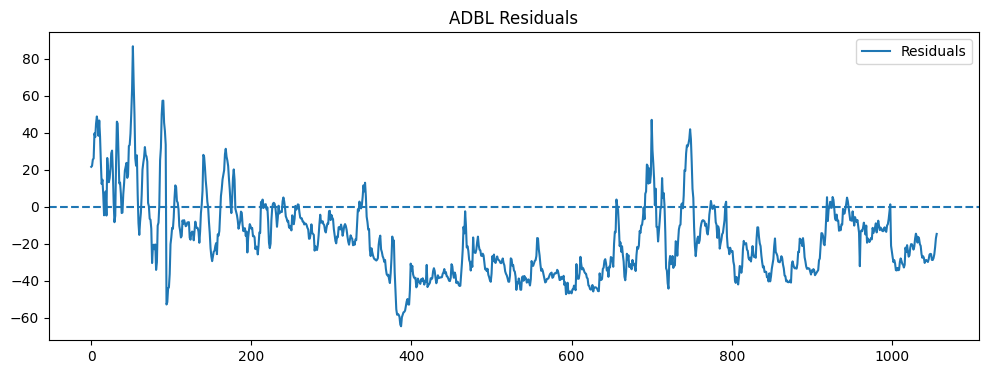

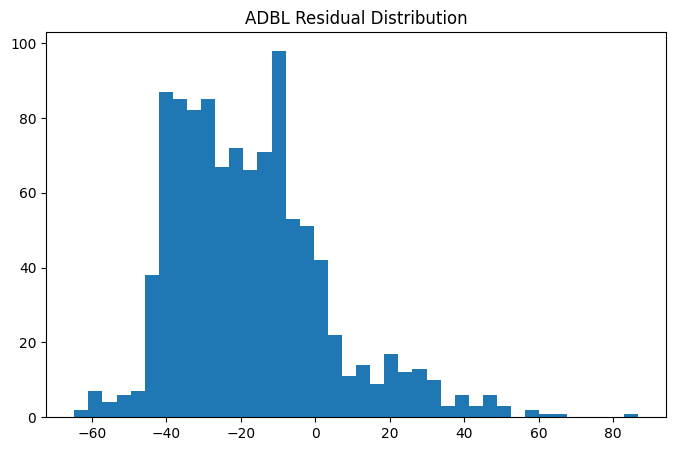

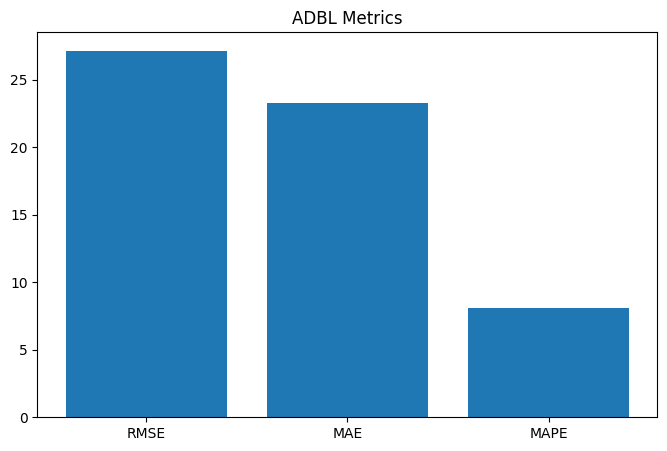

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
Tomorrow Price ADBL: 320.08
Current Price ADBL: 305.00


In [3]:
import os
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from keras.models import Sequential
from keras.layers import Dense, LSTM, Dropout

# Fix Python random
random.seed(42)

# Fix NumPy random
np.random.seed(42)

# Fix TensorFlow random
tf.random.set_seed(42)

# ================= CONFIG =================
TIME_STEPS = 100
EPOCHS = 50
# ================= DATA =================
companyDetails = pd.read_csv("../DATA-HTML-STOCK/NEPSECompany/NEPSECompanyExtractor.csv")
symbols = companyDetails["Symbol"]
print(symbols.head())
stock_ignored  = ["CORBLP", "GFCLPO", "HBLPO", "LFCPO", "SBIPO", "GABLPO", "AMFIPO", "NMLBS", "ILFCPO", "JSLBBP"]
stock_no_news  = ["HATHPO", "BUDBLP", "CFCLPO", "CORBLP", "EBLPO", "HAMROP", "HGIPO", "JFLPO", "JBNLPO",
                  "KADBLP", "KNBLPO", "CEFLPO", "LBLPO", "MFILPO", "MIDBLP", "NBBLPO", "NABBPO", "NBBPO",
                  "PFLPO", "PRINPO", "PURBLP", "SBBLJP", "SIFCPO", "SILPO", "SMFDBP", "SYFLPO", "TNBLPO",
                  "TDBLPO", "UFLPO", "WDBLPO", "WMBFPO", "HLBSLP"]
# needCompareModel = ["ADBL", "BARUN", "API", "NABIL", "NICA", "NTC"]
needCompareModel = ["BARUN"]
all_metrics = []
for symbol in symbols:
    if symbol not in needCompareModel:
        continue
    if symbol in stock_ignored:
        continue

    print(f"\n===== Processing {symbol} =====")

    stock_path = f"../DATA-HTML-STOCK/FinalDataSet/{symbol}.csv"

    if not os.path.exists(stock_path):
        print(f"{symbol}: missing file, skipping.")
        continue

    # ================= LOAD DATA =================
    df = pd.read_csv(stock_path)
    df = df[['Close','Decayed_Sentiment']].dropna()
    df = df.reset_index(drop=True)
    df = df.iloc[::-1].reset_index(drop=True)
    print(df.head())

    # ================= VISUALIZATION =================
    plt.figure(figsize=(12,6))
    plt.plot(df['Close'], label='Close Price')
    plt.title(f"{symbol} Close Price")
    plt.legend()
    plt.show()

    ma100 = df['Close'].rolling(100).mean()
    ma200 = df['Close'].rolling(200).mean()

    plt.figure(figsize=(12,6))
    plt.plot(df['Close'], label='Close')
    plt.plot(ma100, 'r', label='MA100')
    plt.plot(ma200, 'g', label='MA200')
    plt.legend()
    plt.show()

    # ================= TRAIN TEST SPLIT =================
    data = df[['Close','Decayed_Sentiment']]

    train_size = int(len(data) * 0.7)
    data_train = data[:train_size]
    data_test  = data[train_size:]

    # ================= SCALING (FIT ONLY ON TRAIN) =================
    scaler = MinMaxScaler(feature_range=(0,1))
    train_scaled = scaler.fit_transform(data_train)

    # ================= CREATE TRAIN SEQUENCES =================
    x_train, y_train = [], []

    for i in range(TIME_STEPS, len(train_scaled)):
        x_train.append(train_scaled[i-TIME_STEPS:i])
        y_train.append(train_scaled[i, 0])

    x_train, y_train = np.array(x_train), np.array(y_train)

    print("x_train shape:", x_train.shape)

    # ================= MODEL =================
    model = Sequential()
    model.add(LSTM(50, activation='relu', return_sequences=True, input_shape=(TIME_STEPS,2)))
    model.add(Dropout(0.2))

    model.add(LSTM(60, activation='relu', return_sequences=True))
    model.add(Dropout(0.3))

    model.add(LSTM(80, activation='relu', return_sequences=True))
    model.add(Dropout(0.4))

    model.add(LSTM(120, activation='relu'))
    model.add(Dropout(0.5))

    model.add(Dense(1))

    model.compile(optimizer='adam', loss='mean_squared_error')
    history = model.fit(x_train, y_train, epochs=EPOCHS, validation_split=0.2, verbose=1)

    # ================= SAVE MODEL =================
    MODEL_DIR = "../DATA-HTML-STOCK/Models/"
    os.makedirs(MODEL_DIR, exist_ok=True)
    model_path = os.path.join(MODEL_DIR, f"{symbol}_lstm.h5")
    model.save(model_path)
    print(f"Model saved → {model_path}")

    # ================= TEST PREPARATION =================
    past_100 = data_train.tail(TIME_STEPS)
    final_df = pd.concat([past_100, data_test], ignore_index=True)

    # IMPORTANT: NO FIT HERE
    input_scaled = scaler.transform(final_df)

    x_test, y_test = [], []

    for i in range(TIME_STEPS, len(input_scaled)):
        x_test.append(input_scaled[i-TIME_STEPS:i])
        y_test.append(input_scaled[i, 0])

    x_test, y_test = np.array(x_test), np.array(y_test)

    print("x_test shape:", x_test.shape)

    # ================= PREDICTION =================
    y_pred = model.predict(x_test)

    # ================= INVERSE SCALING (CORRECT WAY) =================
    # y_pred = scaler.inverse_transform(y_pred)
    # y_test = scaler.inverse_transform(y_test.reshape(-1,1))

    # ================= INVERSE SCALING FOR MULTI-FEATURE SCALER =================
    # For predicted values
    y_pred_close = y_pred.copy()  # shape (n,1)
    y_pred_full = np.zeros((y_pred_close.shape[0], 2))  # 2 = number of features used in scaler
    y_pred_full[:,0] = y_pred_close[:,0]  # first column = Close
    y_pred_inv = scaler.inverse_transform(y_pred_full)[:,0]  # get only Close

    # For test values
    y_test_close = y_test.reshape(-1,1)
    y_test_full = np.zeros((y_test_close.shape[0], 2))
    y_test_full[:,0] = y_test_close[:,0]
    y_test_inv = scaler.inverse_transform(y_test_full)[:,0]

    y_pred_flat = y_pred_inv
    y_test_flat = y_test_inv

    # ================= METRICS =================
    mse  = mean_squared_error(y_test_flat, y_pred_flat)
    rmse = np.sqrt(mse)
    mae  = mean_absolute_error(y_test_flat, y_pred_flat)
    r2   = r2_score(y_test_flat, y_pred_flat)

    # SAFE MAPE
    mask = y_test_flat != 0
    mape = np.mean(np.abs((y_test_flat[mask] - y_pred_flat[mask]) / y_test_flat[mask])) * 100

    print(f"\n===== Metrics for {symbol} =====")
    print(f"MSE  : {mse:.4f}")
    print(f"RMSE : {rmse:.4f}")
    print(f"MAE  : {mae:.4f}")
    print(f"R²   : {r2:.4f}")
    print(f"MAPE : {mape:.4f}%")
    print(f"Accuracy (100 - MAPE): {100 - mape:.4f}%")


    FIG_DIR   = f"../STOCK-EVALUATION-DATA-FIGURE/{symbol}/"
    os.makedirs(FIG_DIR, exist_ok=True)
    METRIC_FILE = os.path.join(FIG_DIR, "metrics_summary.csv")
    

    # ================= PLOT 1: Train VS Validation Loss =================
    plt.figure(figsize=(10,6))
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title(f'{symbol} Training vs Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss (MSE)')
    plt.legend()
    plt.savefig(os.path.join(FIG_DIR, f"{symbol}_actual_vs_pred.png"))
    plt.show()
    
    # ================= PLOT 1: ACTUAL VS PRED =================
    plt.figure(figsize=(12,6))
    plt.plot(y_test_flat, label='Actual')
    plt.plot(y_pred_flat, label='Predicted')
    plt.legend()
    plt.title(f"{symbol} Actual vs Predicted")
    plt.savefig(os.path.join(FIG_DIR, f"{symbol}_actual_vs_pred.png"))
    plt.show()

    # ================= PLOT 2: RESIDUAL =================
    residuals = y_test_flat - y_pred_flat

    plt.figure(figsize=(12,4))
    plt.plot(residuals, label='Residuals')
    plt.axhline(0, linestyle='--')
    plt.legend()
    plt.title(f"{symbol} Residuals")
    plt.savefig(os.path.join(FIG_DIR, f"{symbol}_residuals.png"))
    plt.show()

    # Plot 3: Residual Histogram
    plt.figure(figsize=(8,5))
    plt.hist(residuals, bins=40)
    plt.title(f"{symbol} Residual Distribution")
    plt.savefig(os.path.join(FIG_DIR, f"{symbol}_residual_dist.png"))
    plt.show()
    plt.close()

    # Plot 4: Metrics Bar
    metrics_plot = {'RMSE': rmse, 'MAE': mae, 'MAPE': mape}
    plt.figure(figsize=(8,5))
    plt.bar(metrics_plot.keys(), metrics_plot.values())
    plt.title(f"{symbol} Metrics")
    plt.savefig(os.path.join(FIG_DIR, f"{symbol}_metrics.png"))
    plt.show()
    plt.close()

    # ================= PLOT 4: METRICS =================
    metrics = {'MSE': mse, 'RMSE': rmse, 'MAE': mae, 'MAPE': mape}
    
    # ================= SAVE METRICS =================
    all_metrics.append({
        "Symbol": symbol,
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2,
        "MAPE": mape
    })

    # ================= SAVE ALL METRICS CSV =================
    metrics_df = pd.DataFrame(all_metrics)
    metrics_df.to_csv(METRIC_FILE, index=False)

    # ================= TOMORROW PREDICTION =================
    last_100_days = data.tail(TIME_STEPS)  
    last_scaled = scaler.transform(last_100_days)
    X_input = np.array([last_scaled])
    tomorrow_scaled = model.predict(X_input, batch_size=1)

    dummy = np.zeros((1, 2))
    dummy[0, 0] = tomorrow_scaled[0, 0]

    tomorrow_price = scaler.inverse_transform(dummy)[0, 0]

    print(f"Tomorrow Price {symbol}: {tomorrow_price:.2f}")

    current_price = data['Close'].iloc[-1]
    print(f"Current Price {symbol}: {current_price:.2f}")



0      ADBL
1       API
2      HATH
3    HATHPO
4      AKPL
Name: Symbol, dtype: str

===== Processing NTC =====
   Close  Decayed_Sentiment
0  446.0                0.0
1  462.0                0.0
2  460.0                0.0
3  458.0                0.0
4  450.0                0.0


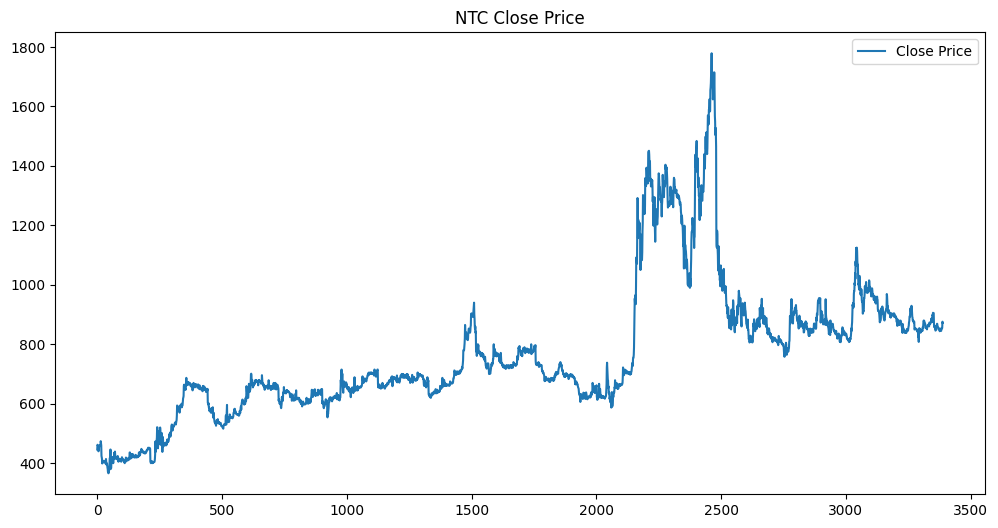

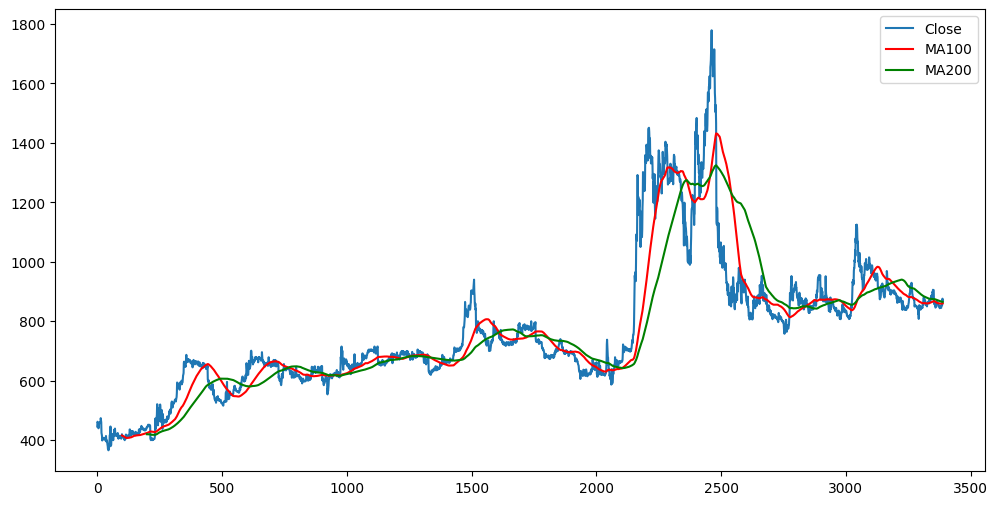

x_train shape: (2272, 100, 2)


/mnt/d/spa/python/venv/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 23s 228ms/step - loss: 0.0108 - val_loss: 0.0122
Epoch 2/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 9s 157ms/step - loss: 0.0030 - val_loss: 0.0223
Epoch 3/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 10s 174ms/step - loss: 0.0022 - val_loss: 0.0130
Epoch 4/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 9s 152ms/step - loss: 0.0023 - val_loss: 0.0297
Epoch 5/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 12s 212ms/step - loss: 0.0019 - val_loss: 0.0156
Epoch 6/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 10s 173ms/step - loss: 0.0018 - val_loss: 0.0213
Epoch 7/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 9s 155ms/step - loss: 0.0018 - val_loss: 0.0141
Epoch 8/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 8s 148ms/step - loss: 0.0015 - val_loss: 0.0169
Epoch 9/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 9s 164ms/step - loss: 0.0015 - val_loss: 0.0106
Epoch 10/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 13s 233ms/step - loss: 0.0014 - val_loss: 0.0204
Epoch 11/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 9s 165ms/step - loss: 0.0012 - val_loss: 0.0178
Epoch 12/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 9s 152ms

Model saved → ../DATA-HTML-STOCK/Models/NTC_lstm.h5
x_test shape: (1017, 100, 2)
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 68ms/step

===== Metrics for NTC =====
MSE  : 11315.0423
RMSE : 106.3722
MAE  : 55.5868
R²   : 0.6568
MAPE : 5.6615%
Accuracy (100 - MAPE): 94.3385%


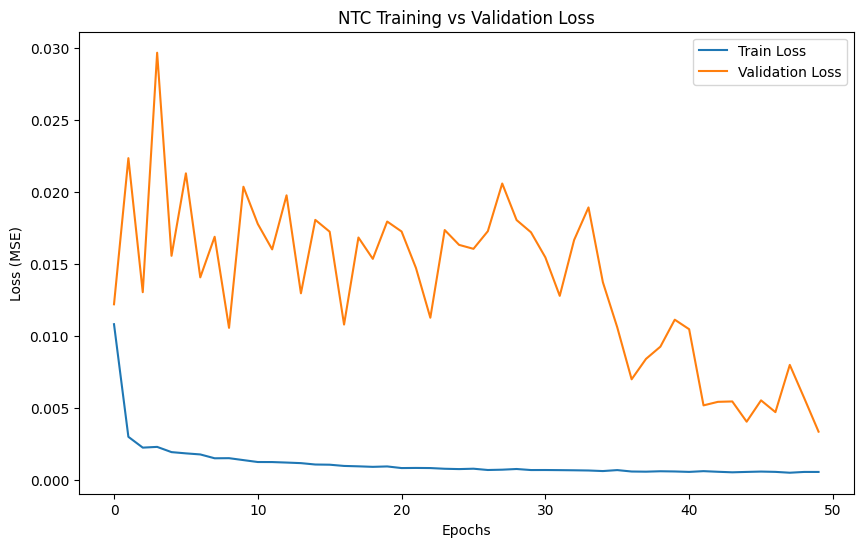

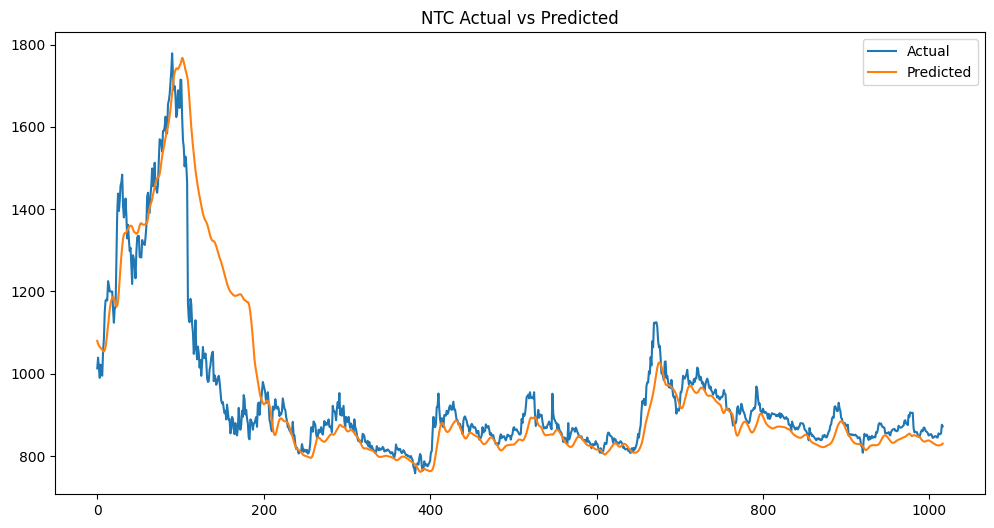

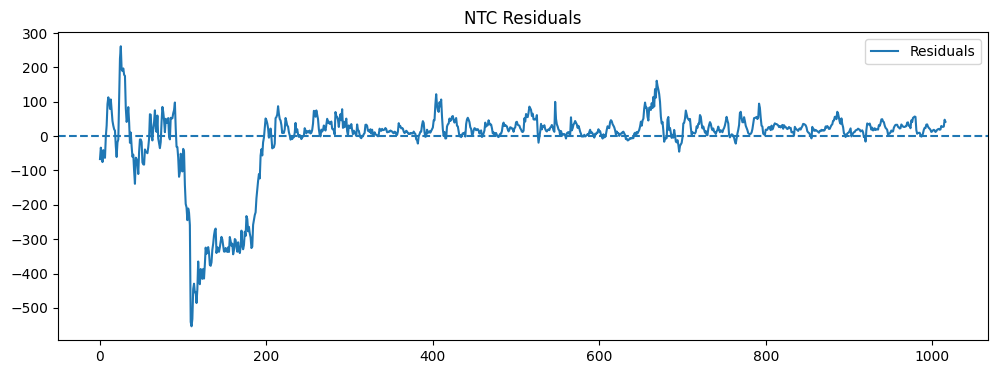

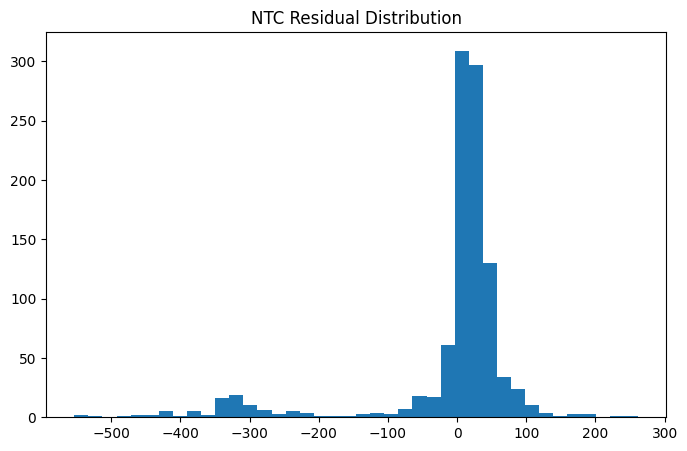

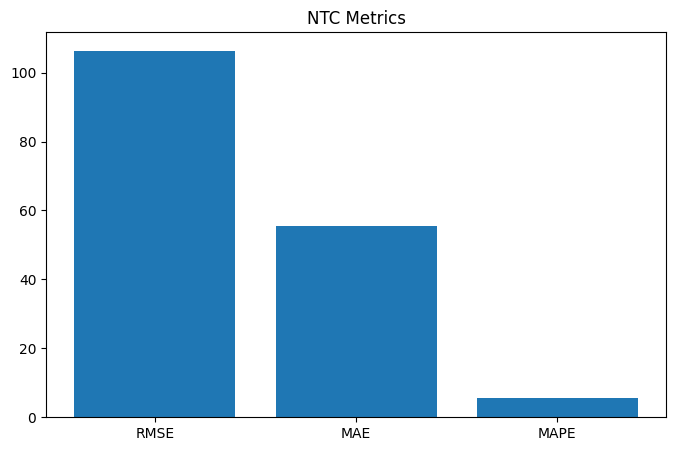

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
Tomorrow Price NTC: 832.88
Current Price NTC: 872.00
Latest date: 2026-03-03
  Backend error: HTTPConnectionPool(host='192.168.254.13', port=80): Max retries exceeded with url: /predicted_price (Caused by ConnectTimeoutError(<HTTPConnection(host='192.168.254.13', port=80) at 0x7950bbfa3aa0>, 'Connection to 192.168.254.13 timed out. (connect timeout=None)'))


In [8]:
import json
import requests
import os
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from keras.models import Sequential
from keras.layers import Dense, LSTM, Dropout

# Fix Python random
random.seed(42)

# Fix NumPy random
np.random.seed(42)

# Fix TensorFlow random
tf.random.set_seed(42)

# ================= CONFIG =================
TIME_STEPS = 100
EPOCHS = 50
# ================= DATA =================
companyDetails = pd.read_csv("../DATA-HTML-STOCK/NEPSECompany/NEPSECompanyExtractor.csv")
symbols = companyDetails["Symbol"]
print(symbols.head())
stock_ignored  = ["CORBLP", "GFCLPO", "HBLPO", "LFCPO", "SBIPO", "GABLPO", "AMFIPO", "NMLBS", "ILFCPO", "JSLBBP"]
stock_no_news  = ["HATHPO", "BUDBLP", "CFCLPO", "CORBLP", "EBLPO", "HAMROP", "HGIPO", "JFLPO", "JBNLPO",
                  "KADBLP", "KNBLPO", "CEFLPO", "LBLPO", "MFILPO", "MIDBLP", "NBBLPO", "NABBPO", "NBBPO",
                  "PFLPO", "PRINPO", "PURBLP", "SBBLJP", "SIFCPO", "SILPO", "SMFDBP", "SYFLPO", "TNBLPO",
                  "TDBLPO", "UFLPO", "WDBLPO", "WMBFPO", "HLBSLP"]
# needCompareModel = ["ADBL", "BARUN", "API", "NABIL", "NICA", "NTC"]
needCompareModel = ["NTC"]
all_metrics = []
for symbol in symbols:
    if symbol not in needCompareModel:
        continue
    if symbol in stock_ignored:
        continue

    print(f"\n===== Processing {symbol} =====")

    stock_path = f"../DATA-HTML-STOCK/FinalDataSet/{symbol}.csv"

    if not os.path.exists(stock_path):
        print(f"{symbol}: missing file, skipping.")
        continue

    # ================= LOAD DATA =================
    df = pd.read_csv(stock_path)
    df = df[['Close','Decayed_Sentiment']].dropna()
    df = df.reset_index(drop=True)
    df = df.iloc[::-1].reset_index(drop=True)
    print(df.head())

    # ================= VISUALIZATION =================
    plt.figure(figsize=(12,6))
    plt.plot(df['Close'], label='Close Price')
    plt.title(f"{symbol} Close Price")
    plt.legend()
    plt.show()

    ma100 = df['Close'].rolling(100).mean()
    ma200 = df['Close'].rolling(200).mean()

    plt.figure(figsize=(12,6))
    plt.plot(df['Close'], label='Close')
    plt.plot(ma100, 'r', label='MA100')
    plt.plot(ma200, 'g', label='MA200')
    plt.legend()
    plt.show()

    # ================= TRAIN TEST SPLIT =================
    data = df[['Close','Decayed_Sentiment']]

    train_size = int(len(data) * 0.7)
    data_train = data[:train_size]
    data_test  = data[train_size:]

    # ================= SCALING (FIT ONLY ON TRAIN) =================
    scaler = MinMaxScaler(feature_range=(0,1))
    train_scaled = scaler.fit_transform(data_train)

    # ================= CREATE TRAIN SEQUENCES =================
    x_train, y_train = [], []

    for i in range(TIME_STEPS, len(train_scaled)):
        x_train.append(train_scaled[i-TIME_STEPS:i])
        y_train.append(train_scaled[i, 0])

    x_train, y_train = np.array(x_train), np.array(y_train)

    print("x_train shape:", x_train.shape)

    # ================= MODEL =================
    model = Sequential()
    model.add(LSTM(50, activation='relu', return_sequences=True, input_shape=(TIME_STEPS,2)))
    model.add(Dropout(0.2))

    model.add(LSTM(60, activation='relu', return_sequences=True))
    model.add(Dropout(0.3))

    model.add(LSTM(80, activation='relu', return_sequences=True))
    model.add(Dropout(0.4))

    model.add(LSTM(120, activation='relu'))
    model.add(Dropout(0.5))

    model.add(Dense(1))

    model.compile(optimizer='adam', loss='mean_squared_error')
    history = model.fit(x_train, y_train, epochs=EPOCHS, validation_split=0.2, verbose=1)

    # ================= SAVE MODEL =================
    MODEL_DIR = "../DATA-HTML-STOCK/Models/"
    os.makedirs(MODEL_DIR, exist_ok=True)
    model_path = os.path.join(MODEL_DIR, f"{symbol}_lstm.h5")
    model.save(model_path)
    print(f"Model saved → {model_path}")

    # ================= TEST PREPARATION =================
    past_100 = data_train.tail(TIME_STEPS)
    final_df = pd.concat([past_100, data_test], ignore_index=True)

    # IMPORTANT: NO FIT HERE
    input_scaled = scaler.transform(final_df)

    x_test, y_test = [], []

    for i in range(TIME_STEPS, len(input_scaled)):
        x_test.append(input_scaled[i-TIME_STEPS:i])
        y_test.append(input_scaled[i, 0])

    x_test, y_test = np.array(x_test), np.array(y_test)

    print("x_test shape:", x_test.shape)

    # ================= PREDICTION =================
    y_pred = model.predict(x_test)

    # ================= INVERSE SCALING (CORRECT WAY) =================
    # y_pred = scaler.inverse_transform(y_pred)
    # y_test = scaler.inverse_transform(y_test.reshape(-1,1))

    # ================= INVERSE SCALING FOR MULTI-FEATURE SCALER =================
    # For predicted values
    y_pred_close = y_pred.copy()  # shape (n,1)
    y_pred_full = np.zeros((y_pred_close.shape[0], 2))  # 2 = number of features used in scaler
    y_pred_full[:,0] = y_pred_close[:,0]  # first column = Close
    y_pred_inv = scaler.inverse_transform(y_pred_full)[:,0]  # get only Close

    # For test values
    y_test_close = y_test.reshape(-1,1)
    y_test_full = np.zeros((y_test_close.shape[0], 2))
    y_test_full[:,0] = y_test_close[:,0]
    y_test_inv = scaler.inverse_transform(y_test_full)[:,0]

    y_pred_flat = y_pred_inv
    y_test_flat = y_test_inv

    # ================= METRICS =================
    mse  = mean_squared_error(y_test_flat, y_pred_flat)
    rmse = np.sqrt(mse)
    mae  = mean_absolute_error(y_test_flat, y_pred_flat)
    r2   = r2_score(y_test_flat, y_pred_flat)

    # SAFE MAPE
    mask = y_test_flat != 0
    mape = np.mean(np.abs((y_test_flat[mask] - y_pred_flat[mask]) / y_test_flat[mask])) * 100

    print(f"\n===== Metrics for {symbol} =====")
    print(f"MSE  : {mse:.4f}")
    print(f"RMSE : {rmse:.4f}")
    print(f"MAE  : {mae:.4f}")
    print(f"R²   : {r2:.4f}")
    print(f"MAPE : {mape:.4f}%")
    print(f"Accuracy (100 - MAPE): {100 - mape:.4f}%")


    FIG_DIR   = f"../STOCK-EVALUATION-DATA-FIGURE/{symbol}/"
    os.makedirs(FIG_DIR, exist_ok=True)
    METRIC_FILE = os.path.join(FIG_DIR, "metrics_summary.csv")
    

    # ================= PLOT 1: Train VS Validation Loss =================
    plt.figure(figsize=(10,6))
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title(f'{symbol} Training vs Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss (MSE)')
    plt.legend()
    plt.savefig(os.path.join(FIG_DIR, f"{symbol}_actual_vs_pred.png"))
    plt.show()
    
    # ================= PLOT 1: ACTUAL VS PRED =================
    plt.figure(figsize=(12,6))
    plt.plot(y_test_flat, label='Actual')
    plt.plot(y_pred_flat, label='Predicted')
    plt.legend()
    plt.title(f"{symbol} Actual vs Predicted")
    plt.savefig(os.path.join(FIG_DIR, f"{symbol}_actual_vs_pred.png"))
    plt.show()

    # ================= PLOT 2: RESIDUAL =================
    residuals = y_test_flat - y_pred_flat

    plt.figure(figsize=(12,4))
    plt.plot(residuals, label='Residuals')
    plt.axhline(0, linestyle='--')
    plt.legend()
    plt.title(f"{symbol} Residuals")
    plt.savefig(os.path.join(FIG_DIR, f"{symbol}_residuals.png"))
    plt.show()

    # Plot 3: Residual Histogram
    plt.figure(figsize=(8,5))
    plt.hist(residuals, bins=40)
    plt.title(f"{symbol} Residual Distribution")
    plt.savefig(os.path.join(FIG_DIR, f"{symbol}_residual_dist.png"))
    plt.show()
    plt.close()

    # Plot 4: Metrics Bar
    metrics_plot = {'RMSE': rmse, 'MAE': mae, 'MAPE': mape}
    plt.figure(figsize=(8,5))
    plt.bar(metrics_plot.keys(), metrics_plot.values())
    plt.title(f"{symbol} Metrics")
    plt.savefig(os.path.join(FIG_DIR, f"{symbol}_metrics.png"))
    plt.show()
    plt.close()

    # ================= PLOT 4: METRICS =================
    metrics = {'MSE': mse, 'RMSE': rmse, 'MAE': mae, 'MAPE': mape}
    
    # ================= SAVE METRICS =================
    all_metrics.append({
        "Symbol": symbol,
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2,
        "MAPE": mape
    })

    # ================= SAVE ALL METRICS CSV =================
    metrics_df = pd.DataFrame(all_metrics)
    metrics_df.to_csv(METRIC_FILE, index=False)

    # ================= TOMORROW PREDICTION =================
    last_100_days = data.tail(TIME_STEPS)  
    last_scaled = scaler.transform(last_100_days)
    X_input = np.array([last_scaled])
    tomorrow_scaled = model.predict(X_input, batch_size=1)

    dummy = np.zeros((1, 2))
    dummy[0, 0] = tomorrow_scaled[0, 0]

    tomorrow_price = scaler.inverse_transform(dummy)[0, 0]

    print(f"Tomorrow Price {symbol}: {tomorrow_price:.2f}")

    current_price = data['Close'].iloc[-1]
    print(f"Current Price {symbol}: {current_price:.2f}")

    df_date = pd.read_csv(stock_path)
    df_date = df_date[['Date_Stock']].dropna()
    df_date = df_date.reset_index(drop=True)
    latest_date = df_date.head(1)['Date_Stock'].values[0]
    print("Latest date:", latest_date)
    
    try:
        requests.post('http://192.168.254.13/predicted_price',json={"predicted_price": float(tomorrow_price), "stock": symbol, "date": latest_date, "current_price": float(current_price)})
        print("  Sent to backend.")
    except Exception as e:
        print(f"  Backend error: {e}")

